**Cell 1 — Imports & Setup**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


**Cell 2 — The Problem: Full Fine-tuning is Expensive**

In [2]:
# Show how many parameters a model has
# and how expensive full fine-tuning is

class SimpleTransformerLayer(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.ff1 = nn.Linear(d_model, d_ff)
        self.ff2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        return x

# Compare parameter counts across model sizes
models = {
    'GPT-2 (small)':   {'layers': 12,  'd_model': 768,   'd_ff': 3072},
    'GPT-2 (large)':   {'layers': 36,  'd_model': 1280,  'd_ff': 5120},
    'LLaMA 1B':        {'layers': 16,  'd_model': 2048,  'd_ff': 8192},
    'LLaMA 7B':        {'layers': 32,  'd_model': 4096,  'd_ff': 11008},
}

print("="*70)
print("MODEL SIZE COMPARISON")
print("="*70)

for name, config in models.items():
    # Rough parameter estimate per layer
    d = config['d_model']
    f = config['d_ff']
    l = config['layers']
    
    # Attention: Q, K, V, O projections
    attn_params = 4 * d * d
    
    # FFN: two linear layers
    ffn_params = 2 * d * f
    
    # Total per layer
    params_per_layer = attn_params + ffn_params
    total_params = params_per_layer * l
    
    # Memory (float32 = 4 bytes, float16 = 2 bytes)
    memory_fp32 = total_params * 4 / (1024**3)
    memory_fp16 = total_params * 2 / (1024**3)
    
    print(f"\n{name}:")
    print(f"  Parameters:     {total_params/1e6:.0f}M")
    print(f"  Memory (fp32):  {memory_fp32:.1f} GB")
    print(f"  Memory (fp16):  {memory_fp16:.1f} GB")
    print(f"  Full fine-tune: {memory_fp32 * 4:.1f} GB (weights + gradients + optimizer)")

MODEL SIZE COMPARISON

GPT-2 (small):
  Parameters:     85M
  Memory (fp32):  0.3 GB
  Memory (fp16):  0.2 GB
  Full fine-tune: 1.3 GB (weights + gradients + optimizer)

GPT-2 (large):
  Parameters:     708M
  Memory (fp32):  2.6 GB
  Memory (fp16):  1.3 GB
  Full fine-tune: 10.5 GB (weights + gradients + optimizer)

LLaMA 1B:
  Parameters:     805M
  Memory (fp32):  3.0 GB
  Memory (fp16):  1.5 GB
  Full fine-tune: 12.0 GB (weights + gradients + optimizer)

LLaMA 7B:
  Parameters:     5033M
  Memory (fp32):  18.8 GB
  Memory (fp16):  9.4 GB
  Full fine-tune: 75.0 GB (weights + gradients + optimizer)


**Cell 3 — What is Low-Rank?**

UNDERSTANDING LOW-RANK MATRICES

Full weight matrix W:
  Shape: torch.Size([8, 8])
  Parameters: 64

LoRA decomposition (rank=2):
  A shape: torch.Size([8, 2]) = 16 parameters
  B shape: torch.Size([2, 8]) = 16 parameters
  A × B shape: torch.Size([8, 8])
  Total LoRA parameters: 32

Compression ratio: 2.0x fewer parameters


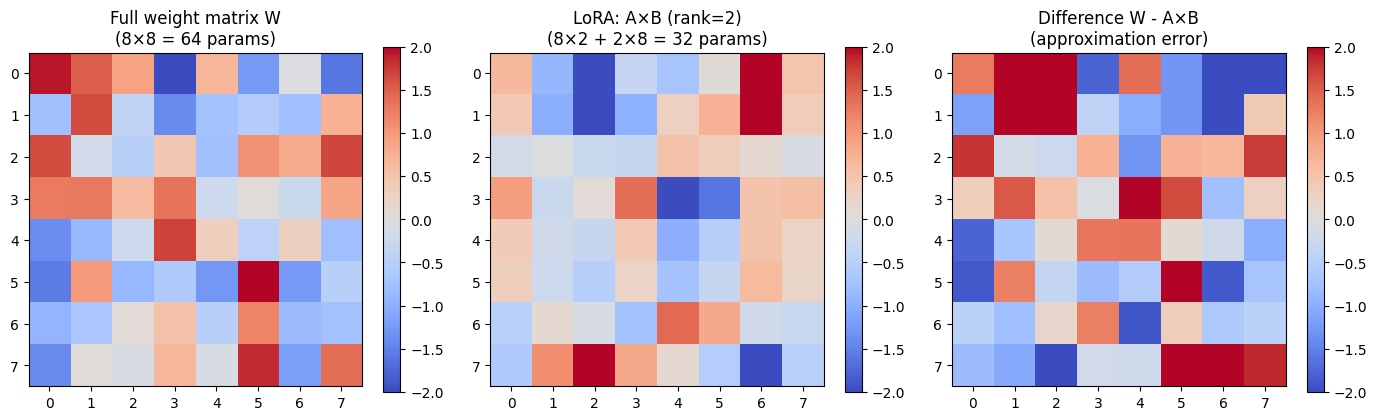


Key insight:
  W has 64 independent values
  A×B has only 32 parameters but approximates W
  Higher rank = better approximation but more parameters


In [3]:
# Demonstrate what "low rank" means visually

print("="*70)
print("UNDERSTANDING LOW-RANK MATRICES")
print("="*70)

d = 8  # Small example

# A full-rank weight matrix (all values independent)
W_full = torch.randn(d, d)

# A low-rank approximation (rank=2)
r = 2
A = torch.randn(d, r)  # tall and thin
B = torch.randn(r, d)  # short and wide
W_low_rank = A @ B     # outer product

print(f"\nFull weight matrix W:")
print(f"  Shape: {W_full.shape}")
print(f"  Parameters: {W_full.numel()}")

print(f"\nLoRA decomposition (rank={r}):")
print(f"  A shape: {A.shape} = {A.numel()} parameters")
print(f"  B shape: {B.shape} = {B.numel()} parameters")
print(f"  A × B shape: {W_low_rank.shape}")
print(f"  Total LoRA parameters: {A.numel() + B.numel()}")

print(f"\nCompression ratio: {W_full.numel() / (A.numel() + B.numel()):.1f}x fewer parameters")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im = axes[0].imshow(W_full.numpy(), cmap='coolwarm', vmin=-2, vmax=2)
axes[0].set_title(f"Full weight matrix W\n({d}×{d} = {d*d} params)")
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(W_low_rank.detach().numpy(), cmap='coolwarm', vmin=-2, vmax=2)
axes[1].set_title(f"LoRA: A×B (rank={r})\n({d}×{r} + {r}×{d} = {2*d*r} params)")
plt.colorbar(im, ax=axes[1])

diff = (W_full - W_low_rank).detach().numpy()
im = axes[2].imshow(diff, cmap='coolwarm', vmin=-2, vmax=2)
axes[2].set_title(f"Difference W - A×B\n(approximation error)")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"\nKey insight:")
print(f"  W has {W_full.numel()} independent values")
print(f"  A×B has only {2*d*r} parameters but approximates W")
print(f"  Higher rank = better approximation but more parameters")

**Cell 4 — LoRA Layer From Scratch**

In [4]:
class LoRALinear(nn.Module):
    """
    A linear layer with LoRA adaptation.
    
    Instead of updating W directly:
      W_new = W + ΔW  (expensive, full rank)
    
    LoRA adds:
      W_new = W + A×B  (cheap, low rank)
    
    Only A and B are trained. W is frozen.
    """
    
    def __init__(self, in_features, out_features, rank=4, alpha=16):
        super().__init__()
        
        # Original linear layer (FROZEN)
        self.linear = nn.Linear(in_features, out_features, bias=False)
        
        # Freeze original weights
        self.linear.weight.requires_grad = False
        
        # LoRA matrices (TRAINABLE)
        self.lora_A = nn.Linear(in_features, rank, bias=False)
        self.lora_B = nn.Linear(rank, out_features, bias=False)
        
        # Scaling factor
        # alpha/rank controls the magnitude of LoRA updates
        self.scaling = alpha / rank
        
        # Initialise A with random, B with zeros
        # This ensures LoRA starts as identity (no change at start)
        nn.init.kaiming_uniform_(self.lora_A.weight)
        nn.init.zeros_(self.lora_B.weight)
        
        self.rank = rank
        self.alpha = alpha
    
    def forward(self, x):
        # Original output (frozen weights)
        original_output = self.linear(x)
        
        # LoRA output (trainable)
        lora_output = self.lora_B(self.lora_A(x)) * self.scaling
        
        # Combined output
        return original_output + lora_output
    
    def get_param_counts(self):
        original = self.linear.weight.numel()
        lora = self.lora_A.weight.numel() + self.lora_B.weight.numel()
        return original, lora

# Test LoRA layer
print("="*70)
print("LORA LINEAR LAYER")
print("="*70)

in_f, out_f = 768, 768  # GPT-2 size
rank = 8

lora_layer = LoRALinear(in_f, out_f, rank=rank, alpha=16)

original_params, lora_params = lora_layer.get_param_counts()
print(f"\nLayer dimensions: {in_f} → {out_f}")
print(f"Rank: {rank}")
print(f"\nOriginal parameters: {original_params:,} (frozen)")
print(f"LoRA parameters:     {lora_params:,} (trainable)")
print(f"Reduction:           {original_params / lora_params:.0f}x fewer trainable params")

# Forward pass
x = torch.randn(2, 10, in_f)
out = lora_layer(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {out.shape}")

# Verify: initially LoRA output is zero (B initialised to zeros)
with torch.no_grad():
    lora_contribution = lora_layer.lora_B(lora_layer.lora_A(x)) * lora_layer.scaling
    print(f"\nLoRA contribution at init (should be ~0): {lora_contribution.abs().mean():.6f}")
    print("(B initialised to zeros, so LoRA starts as identity)")

LORA LINEAR LAYER

Layer dimensions: 768 → 768
Rank: 8

Original parameters: 589,824 (frozen)
LoRA parameters:     12,288 (trainable)
Reduction:           48x fewer trainable params

Input shape:  torch.Size([2, 10, 768])
Output shape: torch.Size([2, 10, 768])

LoRA contribution at init (should be ~0): 0.000000
(B initialised to zeros, so LoRA starts as identity)


**Cell 5 — Apply LoRA to a Simple Model**

In [5]:
class SimpleModel(nn.Module):
    """A simple model to demonstrate LoRA fine-tuning"""
    
    def __init__(self, d_model, num_classes, use_lora=False, rank=4):
        super().__init__()
        
        self.use_lora = use_lora
        
        if use_lora:
            self.layer1 = LoRALinear(d_model, d_model, rank=rank)
            self.layer2 = LoRALinear(d_model, d_model, rank=rank)
        else:
            self.layer1 = nn.Linear(d_model, d_model)
            self.layer2 = nn.Linear(d_model, d_model)
        
        # Classification head (always trainable)
        self.classifier = nn.Linear(d_model, num_classes)
        self.norm = nn.LayerNorm(d_model)
        self.act = nn.GELU()
    
    def forward(self, x):
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.norm(x)
        return self.classifier(x)
    
    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
    def total_params(self):
        return sum(p.numel() for p in self.parameters())

d_model = 768
num_classes = 2

# Full fine-tuning model
full_model = SimpleModel(d_model, num_classes, use_lora=False)

# LoRA model
lora_model = SimpleModel(d_model, num_classes, use_lora=True, rank=8)

print("="*70)
print("FULL FINE-TUNING vs LORA")
print("="*70)

print(f"\nFull Fine-tuning:")
print(f"  Total parameters:     {full_model.total_params():,}")
print(f"  Trainable parameters: {full_model.trainable_params():,}")
print(f"  % trainable:          100.0%")

print(f"\nLoRA Fine-tuning (rank=8):")
print(f"  Total parameters:     {lora_model.total_params():,}")
print(f"  Trainable parameters: {lora_model.trainable_params():,}")
print(f"  % trainable:          {lora_model.trainable_params()/lora_model.total_params()*100:.2f}%")

print(f"\nReduction in trainable params: {full_model.trainable_params()/lora_model.trainable_params():.0f}x")

FULL FINE-TUNING vs LORA

Full Fine-tuning:
  Total parameters:     1,184,258
  Trainable parameters: 1,184,258
  % trainable:          100.0%

LoRA Fine-tuning (rank=8):
  Total parameters:     1,207,298
  Trainable parameters: 27,650
  % trainable:          2.29%

Reduction in trainable params: 43x


**Cell 6 — Compare Ranks**

RANK vs PARAMETER COUNT

Model dimension: 4096
Full weight matrix: 16,777,216 parameters

Rank         LoRA Params    Reduction    % of Full
--------------------------------------------------
1                  8,192        2048x       0.049%
2                 16,384        1024x       0.098%
4                 32,768         512x       0.195%
8                 65,536         256x       0.391%
16               131,072         128x       0.781%
32               262,144          64x       1.562%
64               524,288          32x       3.125%
128            1,048,576          16x       6.250%


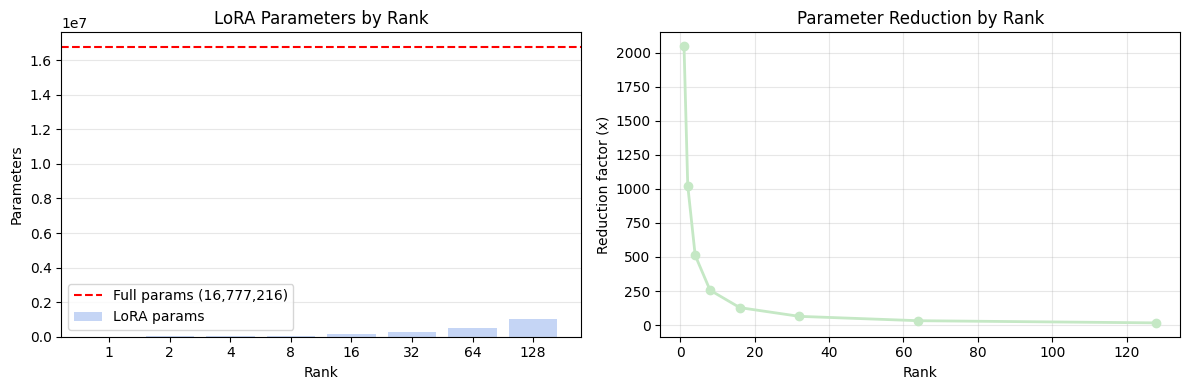


Key insight:
  Rank 8:  65,536 params vs 16,777,216 full (256x reduction)
  Rank 64: 524,288 params vs 16,777,216 full (32x reduction)

In practice: rank 8-64 captures most of the useful adaptation


In [6]:
# Show how rank affects parameter count and expressiveness
print("="*70)
print("RANK vs PARAMETER COUNT")
print("="*70)

d_model = 4096  # LLaMA-style
ranks = [1, 2, 4, 8, 16, 32, 64, 128]

print(f"\nModel dimension: {d_model}")
print(f"Full weight matrix: {d_model * d_model:,} parameters")
print()
print(f"{'Rank':<8} {'LoRA Params':>15} {'Reduction':>12} {'% of Full':>12}")
print("-" * 50)

reductions = []
for r in ranks:
    lora_params = 2 * d_model * r  # A + B
    full_params = d_model * d_model
    reduction = full_params / lora_params
    pct = lora_params / full_params * 100
    reductions.append(reduction)
    print(f"{r:<8} {lora_params:>15,} {reduction:>11.0f}x {pct:>11.3f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
lora_params_list = [2 * d_model * r for r in ranks]
full_params = d_model * d_model
ax.bar([str(r) for r in ranks], lora_params_list, color='#c5d5f5', label='LoRA params')
ax.axhline(y=full_params, color='red', linestyle='--', label=f'Full params ({full_params:,})')
ax.set_xlabel("Rank")
ax.set_ylabel("Parameters")
ax.set_title("LoRA Parameters by Rank")
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(ranks, reductions, marker='o', color='#c5e8c5', linewidth=2)
ax.set_xlabel("Rank")
ax.set_ylabel("Reduction factor (x)")
ax.set_title("Parameter Reduction by Rank")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey insight:")
print(f"  Rank 8:  {2*d_model*8:,} params vs {d_model*d_model:,} full ({d_model*d_model/(2*d_model*8):.0f}x reduction)")
print(f"  Rank 64: {2*d_model*64:,} params vs {d_model*d_model:,} full ({d_model*d_model/(2*d_model*64):.0f}x reduction)")
print(f"\nIn practice: rank 8-64 captures most of the useful adaptation")

**Cell 7 — LoRA Training Demo**

LORA FINE-TUNING DEMO

Dataset: 500 samples, 128 features, 2 classes
Train: 400, Test: 100

LoRA model trainable parameters: 2,562
LoRA model total parameters:     35,330

Training...
  Epoch 10/50 | Loss: 0.3361 | Acc: 0.860
  Epoch 20/50 | Loss: 0.1794 | Acc: 0.938
  Epoch 30/50 | Loss: 0.0838 | Acc: 0.973
  Epoch 40/50 | Loss: 0.0286 | Acc: 0.993
  Epoch 50/50 | Loss: 0.0063 | Acc: 1.000

Test accuracy: 0.960


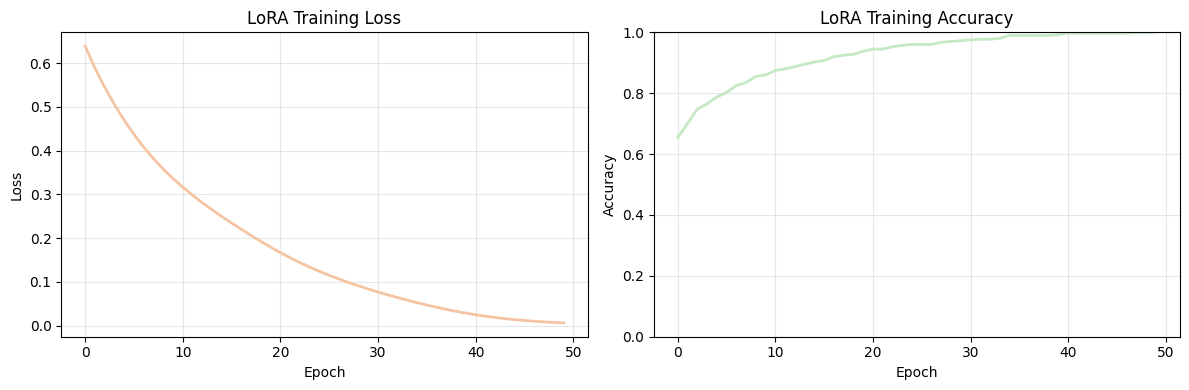

In [7]:
# Demonstrate LoRA fine-tuning on a simple classification task
from torch.optim import AdamW

print("="*70)
print("LORA FINE-TUNING DEMO")
print("="*70)

# Generate synthetic data
# Task: classify whether input has high or low values
n_samples = 500
d_model = 128
num_classes = 2

# Class 0: random noise
# Class 1: slightly shifted distribution
X0 = torch.randn(n_samples // 2, d_model)
X1 = torch.randn(n_samples // 2, d_model) + 0.5

X = torch.cat([X0, X1])
y = torch.cat([torch.zeros(n_samples // 2), torch.ones(n_samples // 2)]).long()

# Shuffle
idx = torch.randperm(n_samples)
X, y = X[idx], y[idx]

# Split
split = int(0.8 * n_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nDataset: {n_samples} samples, {d_model} features, {num_classes} classes")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Create LoRA model
lora_model = SimpleModel(d_model=d_model, num_classes=num_classes, use_lora=True, rank=4)

print(f"\nLoRA model trainable parameters: {lora_model.trainable_params():,}")
print(f"LoRA model total parameters:     {lora_model.total_params():,}")

# Only optimize trainable parameters
optimizer = AdamW(
    [p for p in lora_model.parameters() if p.requires_grad],
    lr=1e-3
)
loss_fn = nn.CrossEntropyLoss()

# Training loop
train_losses = []
train_accs = []

print(f"\nTraining...")
for epoch in range(50):
    lora_model.train()
    
    logits = lora_model(X_train)
    loss = loss_fn(logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    acc = (logits.argmax(dim=1) == y_train).float().mean()
    train_losses.append(loss.item())
    train_accs.append(acc.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Acc: {acc.item():.3f}")

# Evaluate
lora_model.eval()
with torch.no_grad():
    test_logits = lora_model(X_test)
    test_acc = (test_logits.argmax(dim=1) == y_test).float().mean()

print(f"\nTest accuracy: {test_acc.item():.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color='#f5c5a3', linewidth=2)
axes[0].set_title("LoRA Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, color='#c5e8c5', linewidth=2)
axes[1].set_title("LoRA Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Cell 8 — Merge LoRA Weights**

In [8]:
# After training, you can merge LoRA weights back into the original model
# This gives zero inference overhead

print("="*70)
print("MERGING LORA WEIGHTS")
print("="*70)

def merge_lora_weights(lora_layer):
    """
    Merge LoRA weights into base weights.
    W_merged = W + A×B × scaling
    After merging: no extra computation at inference time.
    """
    with torch.no_grad():
        # Get the LoRA update
        lora_update = (lora_layer.lora_B.weight @ lora_layer.lora_A.weight) * lora_layer.scaling
        
        # Add to original weights
        lora_layer.linear.weight.data += lora_update
        
        # Reset LoRA matrices to zero (optional, for cleanliness)
        nn.init.zeros_(lora_layer.lora_A.weight)
        nn.init.zeros_(lora_layer.lora_B.weight)
    
    return lora_layer

# Show before and after merge
test_input = torch.randn(1, d_model)

print(f"\nBefore merge:")
with torch.no_grad():
    out_before = lora_model.layer1(test_input)
    print(f"  Output (first 5 values): {out_before[0, :5].tolist()}")

# Merge
lora_model.layer1 = merge_lora_weights(lora_model.layer1)

print(f"\nAfter merge:")
with torch.no_grad():
    out_after = lora_model.layer1(test_input)
    print(f"  Output (first 5 values): {out_after[0, :5].tolist()}")

print(f"\nOutputs match: {torch.allclose(out_before, out_after, atol=1e-5)}")
print(f"\nAfter merging:")
print(f"  ✅ No extra computation at inference")
print(f"  ✅ Same model size as original")
print(f"  ✅ Same performance as LoRA fine-tuned model")

MERGING LORA WEIGHTS

Before merge:
  Output (first 5 values): [-1.1767334938049316, 0.9116973876953125, 0.21748778223991394, -0.004886031150817871, -0.4609389901161194]

After merge:
  Output (first 5 values): [-1.1767334938049316, 0.9116974472999573, 0.2174878567457199, -0.0048860907554626465, -0.460938960313797]

Outputs match: True

After merging:
  ✅ No extra computation at inference
  ✅ Same model size as original
  ✅ Same performance as LoRA fine-tuned model


**Cell 9 — Summary**

In [9]:
print("""
LORA AND PEFT — SUMMARY

The Problem:
  Fine-tuning large models is expensive
  LLaMA 7B full fine-tune = 112GB GPU memory
  Most people don't have that

The Solution: LoRA
  Freeze original weights W
  Add small trainable matrices A and B
  W_new = W + (A × B) × scaling
  Only train A and B (0.1-1% of parameters)

Why It Works:
  Fine-tuning updates are naturally low-rank
  Most useful adaptation happens in low dimensions
  High rank = better approximation but more params
  Rank 8-64 is usually enough

Benefits:
  ✅ 10-1000x fewer trainable parameters
  ✅ Fits on consumer GPUs
  ✅ Multiple tasks = multiple LoRA adapters
  ✅ Merge weights for zero inference overhead
  ✅ Performance nearly identical to full fine-tuning

QLoRA (even better):
  Base model quantised to 4-bit (saves memory)
  LoRA adapters in fp16 (saves even more)
  Fine-tune 7B model on a laptop GPU!

When to use what:
  LoRA:         General fine-tuning, decent GPU
  QLoRA:        Limited GPU memory, large models
  Full FT:      Maximum performance, lots of compute
  Prompt tuning: No GPU, just prompting

Next: Fine-tune GPT-2 on custom data using LoRA!
""")


LORA AND PEFT — SUMMARY

The Problem:
  Fine-tuning large models is expensive
  LLaMA 7B full fine-tune = 112GB GPU memory
  Most people don't have that

The Solution: LoRA
  Freeze original weights W
  Add small trainable matrices A and B
  W_new = W + (A × B) × scaling
  Only train A and B (0.1-1% of parameters)

Why It Works:
  Fine-tuning updates are naturally low-rank
  Most useful adaptation happens in low dimensions
  High rank = better approximation but more params
  Rank 8-64 is usually enough

Benefits:
  ✅ 10-1000x fewer trainable parameters
  ✅ Fits on consumer GPUs
  ✅ Multiple tasks = multiple LoRA adapters
  ✅ Merge weights for zero inference overhead
  ✅ Performance nearly identical to full fine-tuning

QLoRA (even better):
  Base model quantised to 4-bit (saves memory)
  LoRA adapters in fp16 (saves even more)
  Fine-tune 7B model on a laptop GPU!

When to use what:
  LoRA:         General fine-tuning, decent GPU
  QLoRA:        Limited GPU memory, large models
  Full